In [215]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [216]:
#load dataset
df=pd.read_csv(r"D:\jss_internship\Road.csv")

In [217]:
#first five rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [218]:
#no. of rows and columns
print(df.shape)

(12316, 32)


In [219]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

In [220]:
df.describe(include='object')

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,...,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,...,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415


In [221]:
df.nunique()

Time                           1074
Day_of_week                       7
Age_band_of_driver                5
Sex_of_driver                     3
Educational_level                 7
Vehicle_driver_relation           4
Driving_experience                7
Type_of_vehicle                  17
Owner_of_vehicle                  4
Service_year_of_vehicle           6
Defect_of_vehicle                 3
Area_accident_occured            14
Lanes_or_Medians                  7
Road_allignment                   9
Types_of_Junction                 8
Road_surface_type                 5
Road_surface_conditions           4
Light_conditions                  4
Weather_conditions                9
Type_of_collision                10
Number_of_vehicles_involved       6
Number_of_casualties              8
Vehicle_movement                 13
Casualty_class                    4
Sex_of_casualty                   3
Age_band_of_casualty              6
Casualty_severity                 4
Work_of_casuality           

In [222]:
#target value
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='str')

In [223]:
#numerical feature
numerical=df.select_dtypes(include=['int64','float64']).columns
print(numerical)

Index(['Number_of_vehicles_involved', 'Number_of_casualties'], dtype='str')


In [224]:
#target variable
df.columns[-1]

'Accident_severity'

In [225]:
#viewed summary statics
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [226]:
#percentage and value of missing values
missing=pd.DataFrame({
    "missing values":df.isnull().sum(),
    "percentage":(df.isnull().sum()/len(df))*100
})
print(missing)


                             missing values  percentage
Time                                      0    0.000000
Day_of_week                               0    0.000000
Age_band_of_driver                        0    0.000000
Sex_of_driver                             0    0.000000
Educational_level                       741    6.016564
Vehicle_driver_relation                 579    4.701202
Driving_experience                      829    6.731082
Type_of_vehicle                         950    7.713543
Owner_of_vehicle                        482    3.913608
Service_year_of_vehicle                3928   31.893472
Defect_of_vehicle                      4427   35.945112
Area_accident_occured                   239    1.940565
Lanes_or_Medians                        385    3.126015
Road_allignment                         142    1.152972
Types_of_Junction                       887    7.202014
Road_surface_type                       172    1.396557
Road_surface_conditions                   0    0

Observation:
The dataset contained missing values in several categorical features. The highest percentage of missing values was found in Defect_of_vehicle (35.95%), followed by Service_year_of_vehicle (31.89%) and Fitness_of_casuality (21.39%). Several other categorical columns contained only a small percentage of missing values.

In [227]:
columns_to_fill=[
    'Educational_level',
    'Vehicle_driver_relation',
    'Driving_experience',
    'Type_of_vehicle',
    'Owner_of_vehicle',
    'Area_accident_occured',
    'Lanes_or_Medians',
    'Road_allignment',
    'Road_allignment',
    'Types_of_Junction',
    'Road_surface_type',
    'Type_of_collision',
    'Vehicle_movement'
]
for col in columns_to_fill:
    df[col]=df[col].fillna(df[col].mode()[0])

Observation:
Instead of removing the columns with a high percentage of missing values, the missing entries were replaced with the category "Unknown". This approach preserves all records in the dataset while explicitly identifying unavailable information. The remaining categorical columns, which had only a small percentage of missing values, were imputed using the mode (most frequent value). After preprocessing, the dataset contained no missing values.

In [228]:
#handling missing value
high_missing=['Service_year_of_vehicle',
                  'Defect_of_vehicle',
                  'Work_of_casuality',
                  'Fitness_of_casuality'
]
df[high_missing]=df[high_missing].fillna('unknown')

Observation:
The dataset contains missing values in several categorical features. Most columns have less than 10% missing data, while Service_year_of_vehicle, Defect_of_vehicle,Work_of_casuality and Fitness_of_casuality have a significantly higher percentage of missing values (over 20%).


In [229]:
missing=pd.DataFrame({
    "missing values":df.isnull().sum(),
    "percentage":(df.isnull().sum()/len(df))*100
})
print(missing)


                             missing values  percentage
Time                                      0         0.0
Day_of_week                               0         0.0
Age_band_of_driver                        0         0.0
Sex_of_driver                             0         0.0
Educational_level                         0         0.0
Vehicle_driver_relation                   0         0.0
Driving_experience                        0         0.0
Type_of_vehicle                           0         0.0
Owner_of_vehicle                          0         0.0
Service_year_of_vehicle                   0         0.0
Defect_of_vehicle                         0         0.0
Area_accident_occured                     0         0.0
Lanes_or_Medians                          0         0.0
Road_allignment                           0         0.0
Types_of_Junction                         0         0.0
Road_surface_type                         0         0.0
Road_surface_conditions                   0     

Observation:
After replacing the missing values with appropriate categories, the dataset contained no missing values. This ensures that the data is complete and ready for further preprocessing, feature engineering, and machine learning model training.

In [230]:
df.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Cause_of_a

Observation:
Duplicate records were checked using the duplicated() function. The output showed 0 duplicate rows, indicating that every accident record in the dataset is unique. Therefore, no duplicate records needed to be removed.

In [231]:
df.duplicated().sum()

np.int64(0)

In [232]:
df['Time'].head(10)

0    17:02:00
1    17:02:00
2    17:02:00
3     1:06:00
4     1:06:00
5    14:15:00
6    17:30:00
7    17:20:00
8    17:20:00
9    17:20:00
Name: Time, dtype: str

In [233]:
df['Time']=pd.to_datetime(df['Time'],format='%H:%M:%S')
df['Time'].head()


0   1900-01-01 17:02:00
1   1900-01-01 17:02:00
2   1900-01-01 17:02:00
3   1900-01-01 01:06:00
4   1900-01-01 01:06:00
Name: Time, dtype: datetime64[us]

In [234]:
df['Hour'] = df['Time'].dt.hour

Observation:
A new feature named Time_Period was created from the Time column. The accident time was grouped into four categories: Night (00:00–05:59), Morning (06:00–11:59), Afternoon (12:00–17:59), and Evening (18:00–23:59). This simplifies the time information and helps the model capture patterns related to accident severity at different times of the day.

In [235]:
def time_period(hour):
    if hour<6:
        return "night"
    elif hour<12:
        return "morning"
    elif hour<18:
        return "afternon"
    else:
        return "evening"
df['Time_Period'] = df['Hour'].apply(time_period)

In [236]:
df[['Hour','Time_Period']].head(10)

,Hour,Time_Period
0,17,afternon
1,17,afternon
2,17,afternon
3,1,night
4,1,night
5,14,afternon
6,17,afternon
7,17,afternon
8,17,afternon
9,17,afternon


In [237]:

df.drop('Hour',axis=1,inplace=True)

In [238]:
df.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Cause_of_a

Observation

The dataset was divided into independent variables (X) and the target variable (y). The independent variables contain all accident-related information, while the target variable represents the accident severity to be predicted.

In [239]:
X=df.drop(['Accident_severity', 'Time'],axis=1)
y=df['Accident_severity']
print(X.shape)
print(y.shape)

(12316, 31)
(12316,)


Observation

The dataset was split into training and testing sets using an 80:20 ratio. The stratify parameter was used to preserve the distribution of accident severity classes in both sets, ensuring a fair evaluation of the machine learning model.

In [240]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = X.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [241]:
print(X.dtypes)

Day_of_week                    int64
Age_band_of_driver             int64
Sex_of_driver                  int64
Educational_level              int64
Vehicle_driver_relation        int64
Driving_experience             int64
Type_of_vehicle                int64
Owner_of_vehicle               int64
Service_year_of_vehicle        int64
Defect_of_vehicle              int64
Area_accident_occured          int64
Lanes_or_Medians               int64
Road_allignment                int64
Types_of_Junction              int64
Road_surface_type              int64
Road_surface_conditions        int64
Light_conditions               int64
Weather_conditions             int64
Type_of_collision              int64
Number_of_vehicles_involved    int64
Number_of_casualties           int64
Vehicle_movement               int64
Casualty_class                 int64
Sex_of_casualty                int64
Age_band_of_casualty           int64
Casualty_severity              int64
Work_of_casuality              int64
F

In [242]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42,
    stratify=y)


The dataset was successfully divided into training and testing sets using an 80:20 ratio. The training set contains 8,251 records for model learning, while the testing set contains 4,065 records for evaluating the model's performance. Stratified sampling was used to maintain the class distribution in both sets.

In [243]:
print("X_train:",X_train.shape)
print("X_test :",X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (8251, 31)
X_test : (4065, 31)
y_train: (8251,)
y_test : (4065,)


In [244]:
y_train.value_counts()

Accident_severity
Slight Injury     6977
Serious Injury    1168
Fatal injury       106
Name: count, dtype: int64

In [245]:
print(y_train.value_counts())

Accident_severity
Slight Injury     6977
Serious Injury    1168
Fatal injury       106
Name: count, dtype: int64


In [246]:
!pip install imbalanced-learn


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [247]:
from imblearn.over_sampling import ADASYN

In [248]:
adasyn=ADASYN(random_state=42)

In [249]:
print("===== Data Types =====")
print(X_train.dtypes)

print("\n===== Datetime Columns =====")
print(X_train.select_dtypes(include=['datetime64[ns]']).columns)

print("\n===== Object Columns =====")
print(X_train.select_dtypes(include=['object']).columns)

===== Data Types =====
Day_of_week                    int64
Age_band_of_driver             int64
Sex_of_driver                  int64
Educational_level              int64
Vehicle_driver_relation        int64
Driving_experience             int64
Type_of_vehicle                int64
Owner_of_vehicle               int64
Service_year_of_vehicle        int64
Defect_of_vehicle              int64
Area_accident_occured          int64
Lanes_or_Medians               int64
Road_allignment                int64
Types_of_Junction              int64
Road_surface_type              int64
Road_surface_conditions        int64
Light_conditions               int64
Weather_conditions             int64
Type_of_collision              int64
Number_of_vehicles_involved    int64
Number_of_casualties           int64
Vehicle_movement               int64
Casualty_class                 int64
Sex_of_casualty                int64
Age_band_of_casualty           int64
Casualty_severity              int64
Work_of_casuali

In [250]:
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

# SECTION 9
# Machine Learning Model Development Framework

This section prepares the environment required for developing, training, evaluating, and comparing multiple machine learning models.

In [251]:
print("Before ADASYN")
print(y_train.value_counts())

print()

print("After ADASYN")
print(y_train_resampled.value_counts())

Before ADASYN
Accident_severity
Slight Injury     6977
Serious Injury    1168
Fatal injury       106
Name: count, dtype: int64

After ADASYN
Accident_severity
Serious Injury    7164
Slight Injury     6977
Fatal injury      6946
Name: count, dtype: int64


In [252]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Utilities
import joblib
import time
import warnings

warnings.filterwarnings("ignore")

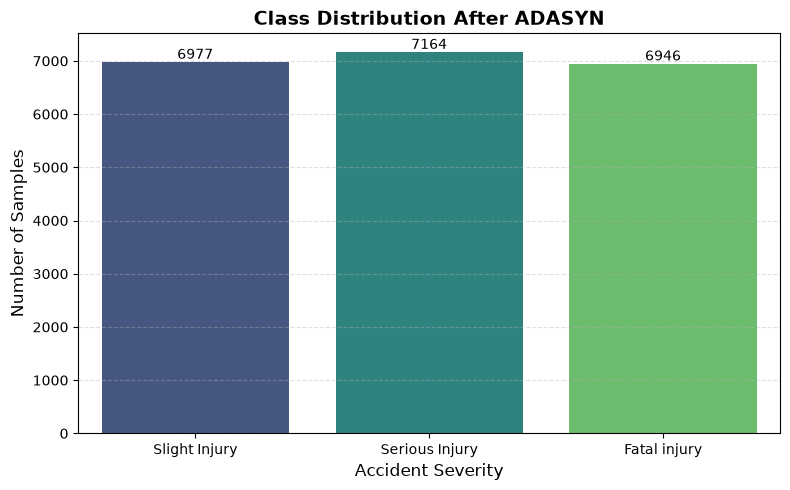

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x=y_train_resampled,
    palette="viridis"
)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution After ADASYN", fontsize=14, fontweight='bold')

plt.xlabel("Accident Severity", fontsize=12)

plt.ylabel("Number of Samples", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The original dataset exhibited a significant class imbalance, with the *Fatal Injury* class containing substantially fewer instances than the *Slight Injury* class. Such imbalance can lead to biased model learning.

To address this issue, the ADASYN (Adaptive Synthetic Sampling) technique was applied to the training dataset. The resulting class distribution is nearly balanced, enabling machine learning models to learn meaningful decision boundaries for all severity classes and improving their ability to generalize.